<a href="https://colab.research.google.com/github/LuisTT0903/Processamento-de-Sinais1/blob/main/pr%C3%A1tica2quest%C3%A3o1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Frequencia de Nyquist (fs/2) = 22050.0 Hz

f pedido =    500 Hz  ->  pico observado em 500.0 Hz  (sem aliasing)
f pedido =   5000 Hz  ->  pico observado em 5000.0 Hz  (sem aliasing)
f pedido =  10000 Hz  ->  pico observado em 10000.0 Hz  (sem aliasing)
f pedido =  50000 Hz  ->  pico observado em 5900.0 Hz  (ALIASING! Alias teorico = 5900 Hz)


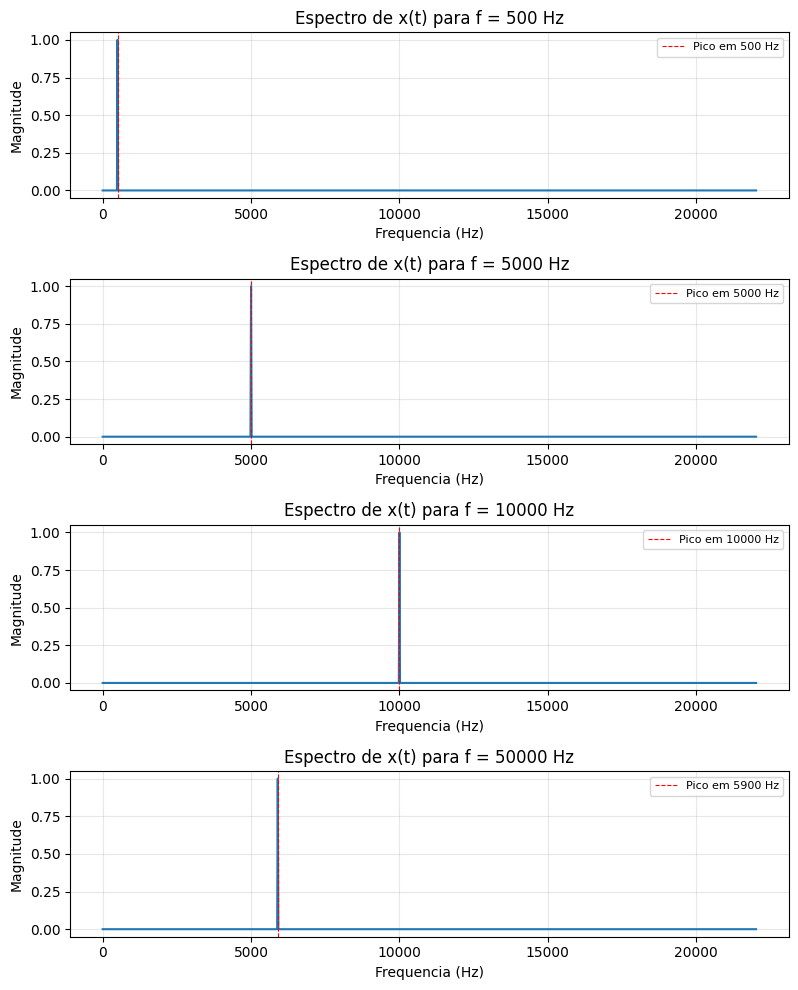

In [ ]:
"""
Questao 1 - Espectro de x(t) = cos(2*pi*f*t) amostrado a fs = 44.1 kHz

Objetivo:
    - Amostrar um cosseno de frequencia f para cada valor em {500, 5000, 10000, 50000} Hz
    - Calcular o espectro de frequencia via FFT (funcao calculate_spectrum)
    - Plotar o modulo do espectro para cada caso, evidenciando o efeito de aliasing
      quando f > fs/2 (frequencia de Nyquist)
"""

import numpy as np
import matplotlib.pyplot as plt


# ---------------------------------------------------------------------------
# Funcao calculate_spectrum
# ---------------------------------------------------------------------------
def calculate_spectrum(x, fs):
    """
    Calcula o espectro de magnitude de um sinal discreto x[n] amostrado a fs.

    Parametros
    ----------
    x  : array_like
         Vetor com as amostras do sinal no tempo.
    fs : float
         Frequencia de amostragem em Hz.

    Retorna
    -------
    freqs : ndarray
         Vetor de frequencias correspondentes (Hz), somente a parte positiva
         (espectro unilateral, de 0 ate fs/2).
    mag   : ndarray
         Magnitude do espectro (normalizada pelo numero de amostras),
         correspondente a cada frequencia em 'freqs'.
    """
    N = len(x)

    # FFT do sinal (retorna espectro bilateral, com frequencias positivas
    # e negativas / "espelhadas")
    X = np.fft.fft(x)

    # Vetor de frequencias associado a cada ponto da FFT
    freqs_completo = np.fft.fftfreq(N, d=1/fs)

    # Mantemos apenas a metade positiva do espectro (0 a fs/2),
    # que e o que normalmente se plota para sinais reais
    metade = N // 2
    freqs = freqs_completo[:metade]

    # Magnitude normalizada (dividindo por N para nao depender do numero
    # de amostras) e multiplicada por 2 para compensar a energia que
    # ficou "escondida" na metade negativa do espectro
    mag = (2.0 / N) * np.abs(X[:metade])

    return freqs, mag


# ---------------------------------------------------------------------------
# Parametros do problema
# ---------------------------------------------------------------------------
fs = 44100          # frequencia de amostragem em Hz (44.1 kHz)
duracao = 0.05       # duracao do sinal em segundos (ajusta a resolucao em frequencia)
t = np.arange(0, duracao, 1/fs)   # vetor de tempo amostrado

frequencias_teste = [500, 5000, 10000, 50000]   # valores de f pedidos no enunciado

f_nyquist = fs / 2
print(f"Frequencia de Nyquist (fs/2) = {f_nyquist} Hz\n")


# ---------------------------------------------------------------------------
# Loop principal: gera x(t), calcula o espectro e plota, para cada f
# ---------------------------------------------------------------------------
fig, eixos = plt.subplots(len(frequencias_teste), 1, figsize=(8, 10))

for i, f in enumerate(frequencias_teste):

    # Gera o sinal cosseno amostrado: x(t) = cos(2*pi*f*t)
    x = np.cos(2 * np.pi * f * t)

    # Calcula o espectro usando a funcao definida acima
    freqs, mag = calculate_spectrum(x, fs)

    # Identifica a frequencia onde ocorre o pico do espectro
    f_pico = freqs[np.argmax(mag)]

    # Verifica se ha aliasing (f pedido > frequencia de Nyquist)
    if f > f_nyquist:
        # Formula do alias para f > fs/2 (dobra do espectro em fs/2)
        f_alias_teorico = abs(f - fs)
        status = f"ALIASING! Alias teorico = {f_alias_teorico} Hz"
    else:
        status = "sem aliasing"

    print(f"f pedido = {f:>6} Hz  ->  pico observado em {f_pico:.1f} Hz  ({status})")

    # Plota o espectro desse caso
    eixos[i].plot(freqs, mag)
    eixos[i].set_title(f"Espectro de x(t) para f = {f} Hz")
    eixos[i].set_xlabel("Frequencia (Hz)")
    eixos[i].set_ylabel("Magnitude")
    eixos[i].axvline(f_pico, color='r', linestyle='--', linewidth=0.8,
                      label=f"Pico em {f_pico:.0f} Hz")
    eixos[i].legend(loc="upper right", fontsize=8)
    eixos[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("espectros.png", dpi=150)   # salva na pasta atual (funciona em qualquer ambiente)
plt.show()

(b) Comentário sobre os resultados

Os espectros gerados confirmam o comportamento previsto pela teoria de amostragem (Nyquist-Shannon):

f = 500 Hz, 5000 Hz e 10000 Hz — em todos esses casos, f < fs/2 = 22050 Hz, então o critério de Nyquist é satisfeito. O espectro mostra um único pico exatamente na frequência esperada (500 Hz, 5000 Hz e 10000 Hz, respectivamente), sem distorção. Isso mostra que, enquanto a frequência do sinal estiver abaixo da metade da frequência de amostragem, a amostragem reconstrói fielmente a informação de frequência do sinal contínuo original.

f = 50000 Hz — aqui o critério de Nyquist é violado, pois 50000 Hz > 22050 Hz. Como consequência, ocorre aliasing: o espectro não mostra nenhum pico em 50000 Hz (o que seria fisicamente impossível de se observar, já que está fora da faixa representável [0, fs/2]) e sim um pico em 5900 Hz. Esse valor corresponde exatamente ao cálculo teórico do alias:

𝑓
𝑎
𝑙
𝑖
𝑎
𝑠
=

∣
𝑓
−
𝑓
𝑠
∣
=
∣
50000
−
44100
∣
=
5900
 Hz
f
alias
	​

=∣f−f
s
	​

∣=∣50000−44100∣=5900 Hz

Ou seja, o sinal de 50 kHz amostrado a 44,1 kHz se torna indistinguível de um cosseno puro de 5900 Hz — a amostragem "confunde" as duas frequências, pois ambas produzem exatamente as mesmas amostras discretas no tempo.

Conclusão geral: o experimento evidencia na prática por que é indispensável respeitar fs ≥ 2·f_max (ou aplicar um filtro anti-aliasing antes da conversão A/D). Quando esse critério não é atendido, componentes de alta frequência são "rebatidos" (folded) para dentro da banda [0, fs/2], corrompendo permanentemente a informação espectral do sinal — esse dado não pode ser recuperado depois, mesmo com processamento posterior, pois a informação de frequência original foi perdida no próprio processo de amostragem.